# 4. PyTEM: Synthetic Inversion Example

This notebook demonstrates a complete 1-D TEM inversion workflow on a synthetic dataset:

1. Define a three-layer synthetic earth model.
2. Compute the forward TEM response.
3. Add realistic power-law noise: $e_i = b\,t_i^{-1/2}$ (absolute noise floor in physical units).
4. Run the regularised Gauss-Newton inversion.
5. Inspect the recovered model, data fit, and convergence.

The inversion theory and Jacobian details are covered in [Notebook 2](../2.%20pytem_getJ.ipynb).


## How to run

- **Requirements:** Python 3.11+ with `numpy`, `scipy`, and `matplotlib`; optionally `numba` (CPU) and `cupy` (GPU) for the accelerated backends. You also need the **`pytem` package from this repository**.
- **Paths:** the import cells locate `pytem` automatically by searching upward from the working directory, so there are no absolute paths to edit. (Alternatively, run `pip install -e .` from the repository root.)
- Run the cells **top to bottom**.


In [ ]:
import sys
import time
import importlib
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

# Locate the pyTEM repo root (the folder containing the `pytem` package) by
# searching upward from the working directory, so no absolute path is needed.
for _root in [Path.cwd(), *Path.cwd().parents]:
    if (_root / "pytem").is_dir():
        if str(_root) not in sys.path:
            sys.path.insert(0, str(_root))
        break

# Forward functions, Jacobians, the roughness operator and the inversion driver
# are all part of the pyTEM library (see pytem_fwd.ipynb and pytem_getJ.ipynb for
# the derivations). We import them here rather than re-deriving them.
from pytem import (
    fwd_circle_central,
    fwd_circle_offset,
    fwd_square_central,
    fwd_square_offset,
    MU0,
    HAS_NUMBA,
    HAS_CUDA,
    HANKEL_FILTERS,
    FOURIER_FILTERS,
    EULER_PARAMS,
    getJ_ana,
    getJ_fd,
    getR,
    invert,
)

# Plotting utilities.
from pytem.plotter import plot_model, plot_sounding, plot_inversion


## 1. Synthetic Data

We start from a synthetic **multi-layer** earth whose resistivity varies smoothly with depth: a background trend with a superimposed undulation, plus localised shallow-resistive, mid-conductive, and deep-resistive features. The forward TEM response of this "true" model (computed with `fwd_circle_central`) is the clean signal that we will contaminate with noise and then attempt to recover by inversion.


In [2]:
# Central-loop acquisition geometry
a     = float(np.sqrt(40.0 ** 2 / np.pi))   # equal-area radius of a 40 x 40 m loop [m]
times = np.logspace(-5, -2, 31)             # gate centre times [s]

depths0 = np.array([0.0, 5.0, 10.0, 20.0, 30.0, 45.0, 100.0])*1.75
thicknesses0 = np.diff(depths0)

z = depths0[:-1]
z_norm = (z - z.min()) / (z.max() - z.min())

base_trend = 180 - 80 * z_norm
undulation = 50 * np.sin(2 * np.pi * 1.2 * z_norm)
shallow_high = 10 * np.exp(-0.5 * ((z_norm - 0.18) / 0.10) ** 2)
mid_low = -50 * np.exp(-0.5 * ((z_norm - 0.60) / 0.12) ** 2)
deep_high = 10 * np.exp(-0.5 * ((z_norm - 0.88) / 0.08) ** 2)
rho0 = base_trend + undulation + shallow_high + mid_low + deep_high

# Forward response of the true model (positive dB/dt convention)
d_clean = -fwd_circle_central(
    thicknesses=thicknesses0,
    resistivities=rho0.tolist(),
    tx_radius=a,
    times=times,
)

print(f'True model : rho = {rho0} Ohm.m, thicknesses = {thicknesses0} m')
print(f'Geometry   : circular Tx loop, radius a = {a:.2f} m')
print(f'Data       : {len(times)} gates from {times[0]:.2e} to {times[-1]:.2e} s')

True model : rho = [181.97880066 216.14358746 220.74327382 112.77050186  36.54972323
 150.60605448] Ohm.m, thicknesses = [ 8.75  8.75 17.5  17.5  26.25 96.25] m
Geometry   : circular Tx loop, radius a = 22.57 m
Data       : 31 gates from 1.00e-05 to 1.00e-02 s


### Noise Model

Real TEM data contain additive noise whose amplitude grows at early times (high-frequency electromagnetic interference) and decays at late times (signal falls below instrument floor).  A commonly used empirical model is the power-law floor:

$$e_i = b\,t_i^{-1/2}$$

where $b$ is a constant in physical units (e.g. V m$^{-2}$ s$^{1/2}$).  The exponent $-1/2$ is motivated by the $t^{-5/2}$ late-time decay of the TEM signal: a fixed signal-to-noise ratio at late times corresponds to noise decaying as $t^{-5/2+2} = t^{-1/2}$ relative to the signal.  The noise is applied as a Gaussian random perturbation with standard deviation $e_i$:

$$d_i^{obs} = d_i^{true}\left(1 + \frac{e_i}{|d_i^{true}|}\,\varepsilon_i\right), \quad \varepsilon_i \sim \mathcal{N}(0,1)$$


In [3]:
rng = np.random.default_rng(42)

# Power-law noise floor:  e_i = b * t_i^{-1/2}
# b has units of  V/m^2 * sqrt(s)  (sets the absolute late-time noise level)
b_noise   = 1e-12                       # noise amplitude coefficient
noise_std = b_noise * times ** (-0.5)   # absolute std per gate [V/m^2]
noise_frac = 0.005                       # relative noise per gate (fraction of signal)

noise_floor =  b_noise * times ** (-0.5)
noise_std   = np.maximum(noise_frac * np.abs(d_clean), noise_floor)
d_obs = d_clean + rng.normal(0.0, noise_std)


## 2. Inversion Setup

The inversion uses a 1-D log-spaced layered mesh with a homogeneous starting model.


In [4]:
from scipy.optimize import root_scalar

def get_thicknesses(n_layers, h0, total_depth):
    """
    Finds growth factor g such that:
    total_depth = h0 * (g^n - 1) / (g - 1)
    """
    # Define objective function f(g) = 0
    def objective(g):
        return h0 * (g**n_layers - 1) / (g - 1) - total_depth

    # Solve numerically for g between 1.0001 and 5.0
    res = root_scalar(objective, bracket=[1.0001, 5.0], method='brentq')

    g = res.root

    thicknesses = h0 * (g ** np.arange(n_layers))

    return thicknesses


n_layers = 30
thicks = get_thicknesses(n_layers=n_layers-1, h0=1.0, total_depth=120.00)
depths = np.concatenate(([0], np.cumsum(thicks)))

thicknesses = np.diff(depths).tolist()
log_resistivities = np.ones(len(thicknesses) + 1) * np.log(100.0)

In [5]:


FWD_HANKEL   = 'key_101'            # Hankel filter
FWD_FOURIER  = 'key_81'            # Fourier filter
FWD_NUMBA    = HAS_NUMBA            # use Numba JIT if available
FWD_CUDA     = HAS_CUDA             # use CUDA if available

### Run Inversion

Start from a homogeneous half-space and iterate until the RMS stabilises.

In [6]:
log_resistivities = np.ones(len(thicknesses) + 1) * np.log(100.0)

result = invert(
    obs_data=d_obs,
    thicknesses=thicknesses,
    log_resistivities=log_resistivities,
    tx_size=a,
    times=times,
    alpha_steps=10,
    maxit=20,
    eps=1e-4,
    noise_std=noise_std,
    use_cuda=HAS_CUDA,
    calc_sens=False,
    transform='euler',
    hankel_filter='key_101',
    fourier_filter='key_81',
    max_noise_frac=0.00,
    plot_alpha=False,
    analytical_j=True,
)

# Unpack result dict
best_rho      = result['resistivities']
iter_rms_list = result['rms_history']
rho_hist      = [np.exp(m) for m in result['model_history']]

# Compute modelled response at final model for plotting
mod_data = -fwd_circle_central(
    thicknesses=thicknesses,
    resistivities=best_rho,
    tx_radius=a,
    times=times,
)


[invert] geometry=circle_central, transform=euler, fwd_backend=numba, jac_backend=numba, analytical_j=True, waveform=False
Observed data: Mean Apparent Resistivity = 118.7 Ohm.m (over 31/31 valid gates)
Alpha start = 23308.214
Iteration   1:  RMS = 82.04
    Alpha = 23308.21,  RMS = 43.27
    Alpha = 18046.70,  RMS = 43.94
    RMS increased - stopping alpha search early.
Iteration   2:  RMS = 43.27
    Alpha = 30103.72,  RMS = 6.77
    Alpha = 23308.21,  RMS = 6.45
    Alpha = 18046.70,  RMS = 6.31
    Alpha = 13972.91,  RMS = 6.31
    RMS increased - stopping alpha search early.
Iteration   3:  RMS = 6.31
    Alpha = 23308.21,  RMS = 4.96
    Alpha = 18046.70,  RMS = 4.46
    Alpha = 13972.91,  RMS = 4.06
    Alpha = 10818.71,  RMS = 3.74
    Alpha = 8376.54,  RMS = 3.48
    Alpha = 6485.65,  RMS = 3.27
    Alpha = 5021.60,  RMS = 3.10
    Alpha = 3888.04,  RMS = 3.00
    Alpha = 3010.37,  RMS = 2.98
    Alpha = 2330.82,  RMS = 3.06
    RMS increased - stopping alpha search early.
Ite

## 3. Results

Summary plots: data fit, RMS convergence history, and recovered resistivity model vs true model.


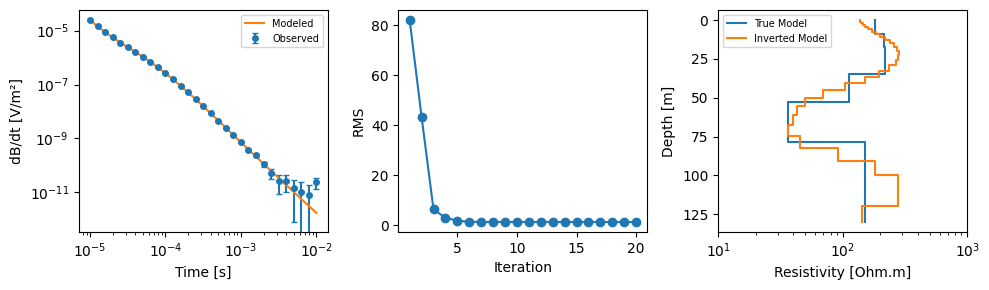

In [7]:
fig, axs = plt.subplots(1, 3, figsize=(10, 3))

# Recompute the noise floor locally so it always matches `times` (later cells
# reuse the name `noise_std` for a different length).
noise_std = b_noise * times ** (-0.5)

axs[0].errorbar(times, d_obs, yerr=noise_std, fmt='o', markersize=4, capsize=2, label='Observed')
axs[0].loglog(times, mod_data, '-', label='Modeled', markersize=4)
axs[0].set_xlabel('Time [s]')
axs[0].set_ylabel('dB/dt [V/m²]')
axs[0].legend(fontsize=7)

axs[1].plot(range(1, len(iter_rms_list) + 1), iter_rms_list, 'o-')
axs[1].set_xlabel('Iteration')
axs[1].set_ylabel('RMS')

depths0 = np.cumsum(np.concatenate(([0], thicknesses0)))
inv_depths = np.concatenate(([0], np.cumsum(thicknesses)))
bottom = inv_depths[-1] + 10   # common bottom depth for both models

axs[2].step(np.r_[rho0, rho0[-1]], np.r_[depths0[:-1], bottom], where='pre', label='True Model')
axs[2].step(np.r_[best_rho, best_rho[-1]], np.r_[inv_depths, bottom], where='pre', label='Inverted Model')

axs[2].invert_yaxis()
axs[2].set_xlabel('Resistivity [Ohm.m]')
axs[2].set_ylabel('Depth [m]')
axs[2].set_xscale('log')
axs[2].legend(fontsize=7)
axs[2].set_xlim(10, 1000)

fig.tight_layout()


## 4. Multi-System Inversion Examples

TEM surveys use a wide range of instrument configurations, from small drone-borne systems to large ground-based loops. Each system sees a different depth range and noise floor. This section inverts synthetic data for a single earth model across three square-loop geometries:

| System | Loop | Geometry | Rx offset | Colour |
|--------|------|----------|-----------|--------|
| Large  | 200 × 200 m | Central square | n/a  | red   |
| Medium | 50 × 50 m   | Central square | n/a  | blue  |
| Small  | 3 × 3 m     | Offset square  | 10 m | green |

Each dataset is inverted with the exact square-loop forward model. The results are summarised in a single figure with three panels: the noisy data, the convergence behaviour (RMS and model roughness), and the recovered resistivity models compared against the truth.

The inversion theory is covered in [Notebook 2](../2.%20pytem_getJ.ipynb); the clean synthetic-example workflow is covered in the sections above.


In [ ]:
import sys
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from pathlib import Path

# Locate the pyTEM repo root (the folder containing the `pytem` package) by
# searching upward from the working directory, so no absolute path is needed.
for _root in [Path.cwd(), *Path.cwd().parents]:
    if (_root / "pytem").is_dir():
        if str(_root) not in sys.path:
            sys.path.insert(0, str(_root))
        break

from pytem import (
    fwd_circle_central,
    fwd_circle_offset,
    fwd_square_central,
    fwd_square_offset,
    getJ_ana,
    getJ_fd,
    getR,
    getRMS,
    invert,
    plot_sounding,
    plot_model,
    plot_inversion,
    MU0,
    HAS_NUMBA,
    HAS_CUDA,
    HANKEL_FILTERS,
    FOURIER_FILTERS,
    EULER_PARAMS,
)

print(f'Numba: {HAS_NUMBA},  CUDA: {HAS_CUDA}')

Numba: True,  CUDA: False


### 4.1 Earth model and survey systems

The same synthetic **multi-layer** earth model defined in Section 1 (a smooth resistivity–depth profile with a background trend, an undulation, and localised resistive/conductive features) is reused here, now investigated across three loop geometries.

The three survey systems span a range of loop sizes and receiver offsets:

| System | Loop | Geometry | Rx offset |
|--------|------|----------|-----------|
| Large  | 200 × 200 m | Central square | n/a |
| Medium | 50 × 50 m   | Central square | n/a |
| Small  | 3 × 3 m     | Offset square  | 10 m |

Larger transmitter moments are recorded from a later first gate, so each system uses its own log-spaced time range.


In [9]:
# --- Earth model (single three-layer model) ---
# Package convention: N resistivities, N-1 finite thicknesses (last layer = half-space).

rho_true   = rho0
thick_true = np.array(thicknesses0)

# --- Three survey systems ---
# (label, L, geom_sq, geom_circ, rx, n_quad, t_first, t_last, n_gate)
# Larger loops carry a bigger moment, so they start at a later first gate.

system_specs = [
    ('200×200 m central', 200.0, 'square_central', None,  3, 5e-5, 5e-2, 31),
    ('50×50 m central',    50.0, 'square_central', None,  3, 1e-5, 1e-2, 31),
    ('3×3 m offset',        3.0, 'square_offset',  10.0, 3, 5e-6, 5e-3, 31),
]

print(f'Earth model: rho={rho_true}  thick={thick_true}')
print()
for s in system_specs:
    print(f'{s[0]:<18}: L={s[1]:>5.0f} m   first gate={s[6]:>5.0e} s   last gate={s[6]:>5.1e} s')


Earth model: rho=[181.97880066 216.14358746 220.74327382 112.77050186  36.54972323
 150.60605448]  thick=[ 8.75  8.75 17.5  17.5  26.25 96.25]

200×200 m central : L=  200 m   first gate=5e-02 s   last gate=5.0e-02 s
50×50 m central   : L=   50 m   first gate=1e-02 s   last gate=1.0e-02 s
3×3 m offset      : L=    3 m   first gate=5e-03 s   last gate=5.0e-03 s


### 4.2 Build synthetic data

Noise-contaminated synthetic data are generated for the earth model on each of the three survey systems (3 datasets). Gaussian noise is added as a fraction of the signal amplitude, with a noise floor proportional to $t^{-0.5}$.

No receiver bandpass or transmitter turn-off ramp is applied; the step response is used directly. Each system samples its own log-spaced time range, with a later first gate for the larger loops (higher moments).


In [10]:
import time

rng = np.random.default_rng(42)

_fwd_kw         = dict(transform='dlf', hankel_filter='key_101', fourier_filter='key_81')
# Relative noise on every gate. The top circle example is near noise-free at the
# informative gates (absolute floor only), so keep this small for a comparable
# high-SNR recovery. Raise it (e.g. 0.03) to see the conductor smear under noise.
noise_frac      = 0.005
noise_floor_amp = 1e-12

# Data-use threshold: a gate is inverted only if its noise is below this
# percentage of the (clean) signal, i.e. SNR >= 100 / max_noise_pct. Gates that
# fail (signal at/below the noise) are excluded and drawn as open circles.
max_noise_pct   = 30.0

t0 = time.perf_counter()
configs = {}
for (s_label, L, geom_sq, rx, nq, t_first, t_last, n_gate) in system_specs:
    times_inv = np.logspace(np.log10(t_first), np.log10(t_last), n_gate)

    if rx is None:
        d_clean = -fwd_square_central(thicknesses0, rho0, L, times_inv, n_quad=nq, **_fwd_kw)
    else:
        d_clean = -fwd_square_offset(thicknesses0, rho0, L, rx, 0.0, times_inv, n_quad=nq, **_fwd_kw)

    L_circ      = L / np.sqrt(np.pi)
    noise_floor = noise_floor_amp * times_inv ** (-0.5)
    noise_std   = np.maximum(noise_frac * np.abs(d_clean), noise_floor)
    d_obs       = d_clean + noise_std * rng.standard_normal(len(d_clean))

    # Keep a gate only if its noise is at most max_noise_pct % of the signal.
    use_mask = noise_std <= (max_noise_pct / 100.0) * np.abs(d_clean)

    configs[s_label] = dict(
        system=s_label,
        rho_true=rho_true, thick_true=thick_true,
        L=L, L_circ=L_circ, geom_sq=geom_sq,
        rx=rx, n_quad=nq, times_inv=times_inv,
        d_clean=d_clean, d_obs_inv=d_obs, noise_std_inv=noise_std,
        use_mask=use_mask,
    )
    print(f'{s_label:<20}: {int(use_mask.sum())}/{n_gate} gates used '
          f'(noise <= {max_noise_pct:.0f}% of signal)')

print(f'\n{len(configs)} datasets built in {time.perf_counter()-t0:.2f} s')


200×200 m central   : 24/31 gates used (noise <= 30% of signal)
50×50 m central     : 25/31 gates used (noise <= 30% of signal)
3×3 m offset        : 17/31 gates used (noise <= 30% of signal)

3 datasets built in 0.97 s


### 4.3 Inversion: exact square loop

Each of the three datasets is inverted with the exact square-loop forward model (Gauss-Legendre quadrature over the loop sides), starting from a homogeneous 100 Ohm.m half-space. The starting model, mesh, and regularisation schedule are identical across the three systems, so the differences in the recovered models come purely from the loop geometry, time range, and noise of each system.


In [11]:
# Example: 15 layers, h0 = 1.0, reaching 120 m depth
n_layers = 30
thick_inv = get_thicknesses(n_layers=n_layers-1, h0=1.0, total_depth=120.00)
depths_inv = np.concatenate(([0], np.cumsum(thick_inv)))
bottom = depths_inv[-1] + 10   # common bottom depth for both models

# Starting model: homogeneous 100 Ohm.m half-space
rho_start  = np.ones(n_layers) * 100.0
lrho_start = np.log(rho_start)

# One colour per survey system (used in the summary figure).
sys_colors = {
    '200×200 m central': 'red',
    '50×50 m central':   'blue',
    '3×3 m offset':      'green',
}

results_sq = {}
timings    = {}

for key, cfg in configs.items():
    rx_kw = dict(rx_x=cfg['rx']) if cfg['rx'] is not None else {}
    m     = cfg['use_mask']   # invert only gates that pass the SNR threshold

    t0 = time.perf_counter()
    res = invert(
        obs_data          = cfg['d_obs_inv'][m],
        thicknesses       = thick_inv,
        log_resistivities = lrho_start,
        times             = cfg['times_inv'][m],
        noise_std         = cfg['noise_std_inv'][m],
        tx_size           = cfg['L'],
        geometry          = cfg['geom_sq'],
        n_quad            = cfg['n_quad'],
        max_noise_frac    = 0.0,
        alpha_start       = None,
        alpha_steps       = 10,
        maxit             = 15,
        transform         = 'euler',
        hankel_filter     = 'key_101',
        fourier_filter    = 'key_81',
        use_numba         = HAS_NUMBA,
        use_cuda          = HAS_CUDA,
        calc_sens         = False,
        analytical_j      = True,
        **rx_kw,
    )

    timings[key] = time.perf_counter() - t0
    results_sq[key] = res
    print(f'{cfg["system"]:<20}  {timings[key]:>5.1f} s   '
          f'gates={int(m.sum())}/{len(m)}   iters={len(res["rms_history"])}   '
          f'final RMS={res["rms_history"][-1]:.2f}')


[invert] geometry=square_central, transform=euler, fwd_backend=numba, jac_backend=numba, analytical_j=True, waveform=False
Observed data: Mean Apparent Resistivity = 120.5 Ohm.m (over 24/24 valid gates)
Alpha start = 18904.111
Iteration   1:  RMS = 23.37
    Alpha = 18904.11,  RMS = 16.88
    Alpha = 14636.77,  RMS = 18.24
    RMS increased - stopping alpha search early.
Iteration   2:  RMS = 16.88
    Alpha = 24415.60,  RMS = 5.09
    Alpha = 18904.11,  RMS = 4.41
    Alpha = 14636.77,  RMS = 3.89
    Alpha = 11332.72,  RMS = 3.48
    Alpha = 8774.51,  RMS = 3.16
    Alpha = 6793.79,  RMS = 2.93
    Alpha = 5260.18,  RMS = 2.76
    Alpha = 4072.77,  RMS = 2.66
    Alpha = 3153.40,  RMS = 2.64
    Alpha = 2441.56,  RMS = 2.74
    RMS increased - stopping alpha search early.
Iteration   3:  RMS = 2.64
    Alpha = 4072.77,  RMS = 2.51
    Alpha = 3153.40,  RMS = 2.30
    Alpha = 2441.56,  RMS = 2.11
    Alpha = 1890.41,  RMS = 1.93
    Alpha = 1463.68,  RMS = 1.78
    Alpha = 1133.27,  R

### 4.4 Summary figure

Three panels summarise the inversion for all three systems (red = 200 × 200 m, blue = 50 × 50 m, green = 3 × 3 m offset):

- **(a) Data:** the noisy observed data (dots) over the clean forward response (lines).
- **(b) Convergence:** data RMS (solid, left axis) and model roughness $m^T R\, m$ (dashed, right axis) versus iteration.
- **(c) Model recovery:** the recovered resistivity profiles against the true model (black).


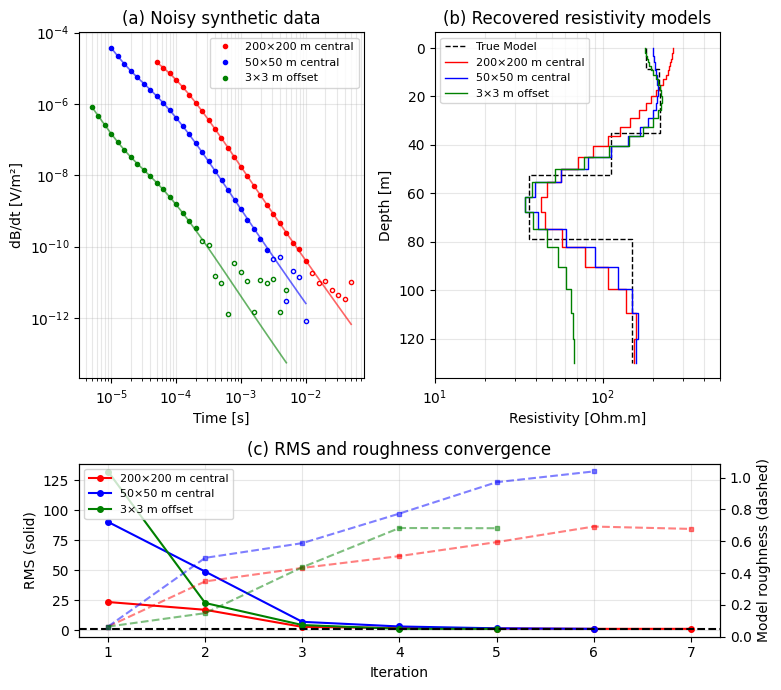

In [18]:
# ===================== figure layout options =====================
LEFT_METRIC   = 'rms'         # 'rms' or 'data_misfit'      -> bottom panel, solid lines
RIGHT_METRIC  = 'roughness'   # 'roughness', 'model_misfit', 'cum_time', or None -> bottom panel, dashed lines

# Relative panel sizes: [top-row height, bottom-row height] and [top-row col-1, col-2 width].
# Edit these to change how much space each row/column gets; ratios only need to be
# relative to each other (e.g. [2, 1] makes the top row twice as tall as the bottom).
# WIDTH_RATIOS only affects the two top panels — the bottom panel always spans full width.
HEIGHT_RATIOS = [2, 1]
WIDTH_RATIOS  = [1, 1]
# ===================================================================

def true_step(rho_true, thick_true):
    """Step-function (rho, depth) arrays for the true model."""
    deps = np.concatenate(([0], np.cumsum(thick_true), [depths_inv[-1]]))
    rho  = np.concatenate([np.repeat(rho_true[:-1], 2), [rho_true[-1], rho_true[-1]]])
    return rho, np.repeat(deps, 2)[1:-1]

def inv_step(res):
    """Step-function (rho, depth) arrays for an inversion result."""
    depths_r = np.concatenate(([0], np.cumsum(res['thicknesses'])))
    rho_step = np.repeat(res['resistivities'], 2)
    dep_step = np.repeat(np.append(depths_r, depths_inv[-1]), 2)[1:-1]
    return rho_step, dep_step

R_op = getR(lrho_start)   # roughness operator for model-roughness history

# True log-resistivity sampled on the inversion-mesh layer centres (model misfit).
# N resistivities but only N-1 finite boundaries, so append the half-space layer.
_centres  = 0.5 * (depths_inv[:-1] + depths_inv[1:])          # N-1 finite-layer centres
_centres  = np.append(_centres, depths_inv[-1])              # + half-space -> N centres
_tops     = depths0[:-1]
_true_idx = np.clip(np.searchsorted(_tops, _centres, side='right') - 1, 0, len(rho0) - 1)
_ln_true  = np.log(np.asarray(rho0)[_true_idx])

def left_series(key, res):
    rms = np.asarray(res['rms_history'], dtype=float)
    if LEFT_METRIC == 'data_misfit':
        n_used = int(configs[key]['use_mask'].sum())
        return rms ** 2 * n_used            # Phi_d = RMS^2 * N_data
    return rms

def right_series(key, res):
    mh = res['model_history']
    if RIGHT_METRIC == 'roughness':
        return np.array([float(m @ R_op @ m) for m in mh])
    if RIGHT_METRIC == 'model_misfit':
        return np.array([float(np.sqrt(np.mean((m - _ln_true) ** 2))) for m in mh])
    if RIGHT_METRIC == 'cum_time':
        n = len(mh)
        return np.linspace(timings[key] / n, timings[key], n)   # approx cumulative wall time
    return None

LEFT_LABEL  = {'rms': 'RMS', 'data_misfit': r'Data misfit $\Phi_d$'}[LEFT_METRIC]
RIGHT_LABEL = {'roughness':    r'Model roughness',
               'model_misfit': r'Model misfit (RMS $\ln\rho$)',
               'cum_time':     'Cumulative time [s]',
               None:           None}[RIGHT_METRIC]

fig = plt.figure(figsize=(8, 7))
gs = fig.add_gridspec(2, 2, height_ratios=HEIGHT_RATIOS, width_ratios=WIDTH_RATIOS)
ax_data  = fig.add_subplot(gs[0, 0])
ax_model = fig.add_subplot(gs[0, 1])
ax_conv  = fig.add_subplot(gs[1, :])   # bottom row spans both columns

# --- (a) Data with noise ---
for key, cfg in configs.items():
    c = sys_colors[key]
    t = cfg['times_inv']
    d = np.abs(cfg['d_obs_inv'])
    m = cfg['use_mask']
    ax_data.loglog(t, np.abs(cfg['d_clean']), '-', color=c, lw=1.2, alpha=0.6)
    ax_data.loglog(t[m],  d[m],  '.', color=c, ms=6, label=key)                 # used
    ax_data.loglog(t[~m], d[~m], '.', mfc='none', mec=c, ms=6)                  # excluded
ax_data.set_xlabel('Time [s]')
ax_data.set_ylabel(r'dB/dt [V/m²]')
ax_data.set_title('(a) Noisy synthetic data')
ax_data.legend(fontsize=8)
ax_data.grid(True, which='both', alpha=0.3)

# --- (b) Model recovery ---
rho_t, dep_t = true_step(rho0, thicknesses0)
ax_model.step(np.r_[rho0, rho0[-1]], np.r_[depths0[:-1], bottom], where='pre',
              label='True Model', color='black', lw=1, ls='--')
for key, res in results_sq.items():
    rho_step, dep_step = inv_step(res)
    ax_model.semilogx(np.r_[rho_step, rho_step[-1]], np.r_[dep_step, bottom],
                       '-', lw=1, color=sys_colors[key], label=key)
ax_model.invert_yaxis()
ax_model.set_xlabel('Resistivity [Ohm.m]')
ax_model.set_ylabel('Depth [m]')
ax_model.set_title('(b) Recovered resistivity models')
ax_model.legend(fontsize=8)
ax_model.grid(True, which='both', alpha=0.3)
ax_model.set_xlim(10, 500)

# --- (c) Convergence: left metric (solid) and optional right metric (dashed) ---
ax_rough = ax_conv.twinx() if RIGHT_METRIC is not None else None
for key, res in results_sq.items():
    c  = sys_colors[key]
    ly = left_series(key, res)
    ax_conv.plot(np.arange(1, len(ly) + 1), ly, '-o', color=c, ms=4, label=key)
    if ax_rough is not None:
        ry = right_series(key, res)
        ax_rough.plot(np.arange(1, len(ry) + 1), ry, '--s', color=c, ms=3, alpha=0.5)
if LEFT_METRIC == 'rms':
    ax_conv.axhline(1.0, color='k', lw=1.5, ls='--')
ax_conv.set_xlabel('Iteration')
ax_conv.set_ylabel(LEFT_LABEL + (' (solid)' if ax_rough is not None else ''))
if ax_rough is not None:
    ax_rough.set_ylabel(RIGHT_LABEL + ' (dashed)')
    if RIGHT_METRIC == 'roughness':
        ax_rough.set_ylim(0,)
ax_conv.set_title('(c) RMS and roughness convergence')
ax_conv.legend(fontsize=8, loc='upper left')
ax_conv.grid(True, which='both', alpha=0.3)

fig.tight_layout()
plt.show()

In [15]:
timings

{'200×200 m central': 15.074990299995989,
 '50×50 m central': 12.95769680000376,
 '3×3 m offset': 7.924807699979283}